In [44]:
import pandas as pd
import numpy as np
import seaborn as sns

In [45]:
def bland_altman_plot(data1, data2, cohort, title, fig_scaler=12, *args, **kwargs):
    data1 = np.asarray(data1)
    data2 = np.asarray(data2)
    n_samples = len(data1)

    mean = np.mean([data1, data2], axis=0)
    diff = data1 - data2
    md   = np.mean(diff)
    sd   = np.std(diff, axis=0)

    plt.figure(figsize=(fig_scaler, fig_scaler * 5 / 8))

    palette = sns.color_palette("bright", len(cohort.unique()))
    sns.scatterplot(x=mean, y=diff, hue=cohort, palette=palette, *args, **kwargs)

    plt.axhline(md,           color='gray', linestyle='--')
    plt.axhline(md + 1.96*sd, color='gray', linestyle='--')
    plt.axhline(md - 1.96*sd, color='gray', linestyle='--')
    plt.title(title)
    plt.xlabel("Mean of mocap and mobgap")
    plt.ylabel("Diff between mocap and mobgap")
    plt.legend(bbox_to_anchor=(1.05, 1), prop = { "size": 18 }, loc='upper left')

    plt.tight_layout()
    plt.show()

def errors(mobgap_wb_dmo, mocap_wb_dmo):
    absolute_error = []
    relative_error = []
    for SS, RS in zip(mobgap_wb_dmo, mocap_wb_dmo):
        absolute_error.append(abs(SS-RS))
        relative_error = abs((SS-RS)/RS)*100
    mae = np.nanmean(absolute_error)
    upper_loa = mae + 1.96*np.nanstd(absolute_error)
    lower_loa = mae - 1.96*np.nanstd(absolute_error)
    return absolute_error, relative_error, mae, upper_loa, lower_loa

def calc_metrics(cur_metrics_ser, cur_subgroup_metrics):
    cur_metrics_ser["Accuracy"] = (cur_subgroup_metrics["wb_TPs"].sum() + cur_subgroup_metrics["wb_TNs"].sum())/(cur_subgroup_metrics["wb_TPs"].sum() + cur_subgroup_metrics["wb_TNs"].sum() + cur_sub_metrics["wb_FPs"].sum() + cur_subgroup_metrics["wb_FNs"].sum())
    cur_metrics_ser["Sensitivity"] = (cur_subgroup_metrics["wb_TPs"].sum())/(cur_subgroup_metrics["wb_TPs"].sum() + cur_subgroup_metrics["wb_FNs"].sum())
    cur_metrics_ser["Positive Predictive Value"] = (cur_subgroup_metrics["wb_TPs"].sum())/(cur_subgroup_metrics["wb_TPs"].sum() + cur_subgroup_metrics["wb_FPs"].sum())
    cur_metrics_ser["Specificity"] = (cur_subgroup_metrics["wb_TNs"].sum())/(cur_subgroup_metrics["wb_TNs"].sum() + cur_subgroup_metrics["wb_FPs"].sum())
    cur_metrics_ser["F1 Score"] = (2*cur_metrics_ser["Positive Predictive Value"]*cur_metrics_ser["Sensitivity"])/(cur_metrics_ser["Positive Predictive Value"]+cur_metrics_ser["Sensitivity"])
    return cur_metrics_ser

,Unnamed: 0,cohort,subject,file_name,wb_ID,wb_TPs,wb_FPs,wb_FNs,wb_TNs,mobgap_ICs,...,IC_FNs,stride_length_mobgap,stride_length_mocap,cadence_mocap,cadence_mobgap,walking_speed_mocap,walking_speed_mobgap,IC_Sensitivity,IC_Positive_Predictive_Value,IC_F1_Score
0,0,CP,582,standing.tsv,NaN,0,0,0,1,0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,CP,582,10m_walk.tsv,1.0,1,0,0,0,16,...,0,1.769917,1.488520,117.117117,117.146761,1.341009,1.728357,1.000000,0.875000,0.933333
2,2,CP,582,10m_walk_bag.tsv,1.0,1,0,0,0,14,...,1,1.539885,1.433436,116.244411,116.502703,1.281761,1.494918,0.928571,0.928571,0.928571
3,3,CP,582,10m_walk_utensils.tsv,1.0,1,0,0,0,16,...,1,1.577739,1.401766,113.924051,112.242503,1.242071,1.477209,0.937500,0.937500,0.937500
4,4,CP,582,10m_walk_utensils.tsv,2.0,1,0,0,0,18,...,1,1.596463,1.410066,116.363636,116.244042,1.343577,1.547572,0.941176,0.888889,0.914286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,101,PSP,864,10m_walk_step.tsv,1.0,1,0,0,0,25,...,3,0.833310,0.815923,88.283379,92.043252,0.578038,0.648555,0.892857,1.000000,0.943396
102,102,PSP,864,tug.tsv,1.0,1,0,0,0,21,...,2,0.603980,0.658141,83.090379,82.225540,0.431725,0.413579,0.900000,0.857143,0.878049
103,103,PSP,864,TCW.tsv,NaN,0,0,1,0,0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104,104,PSP,864,TCCW.tsv,1.0,1,0,0,0,78,...,3,0.779863,0.784801,94.010313,94.682662,0.607045,0.619682,0.962500,0.987179,0.974684


,Subject,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score
0,582,CP,1.0,1.0,1.0,1.0,1.0
0,875,CP,0.888889,0.875,1.0,1.0,0.933333
0,234,CP,0.888889,0.875,1.0,1.0,0.933333
0,855,CP,1.0,1.0,1.0,1.0,1.0
0,884,CP,0.888889,0.875,1.0,1.0,0.933333
0,718,CP,1.0,1.0,1.0,1.0,1.0
0,383,CP,1.0,1.0,1.0,1.0,1.0
0,899,PSP,0.9,1.0,0.5,0.888889,0.941176
0,126,PSP,0.888889,0.875,1.0,1.0,0.933333
0,836,PSP,1.0,1.0,1.0,1.0,1.0


,Cohort,Accuracy,Sensitivity,Specificity,Positive Predictive Value,F1 Score
0,CP,0.955224,0.95,1.0,1.0,0.974359
0,PSP,0.947368,0.941176,0.8,0.969697,0.955224


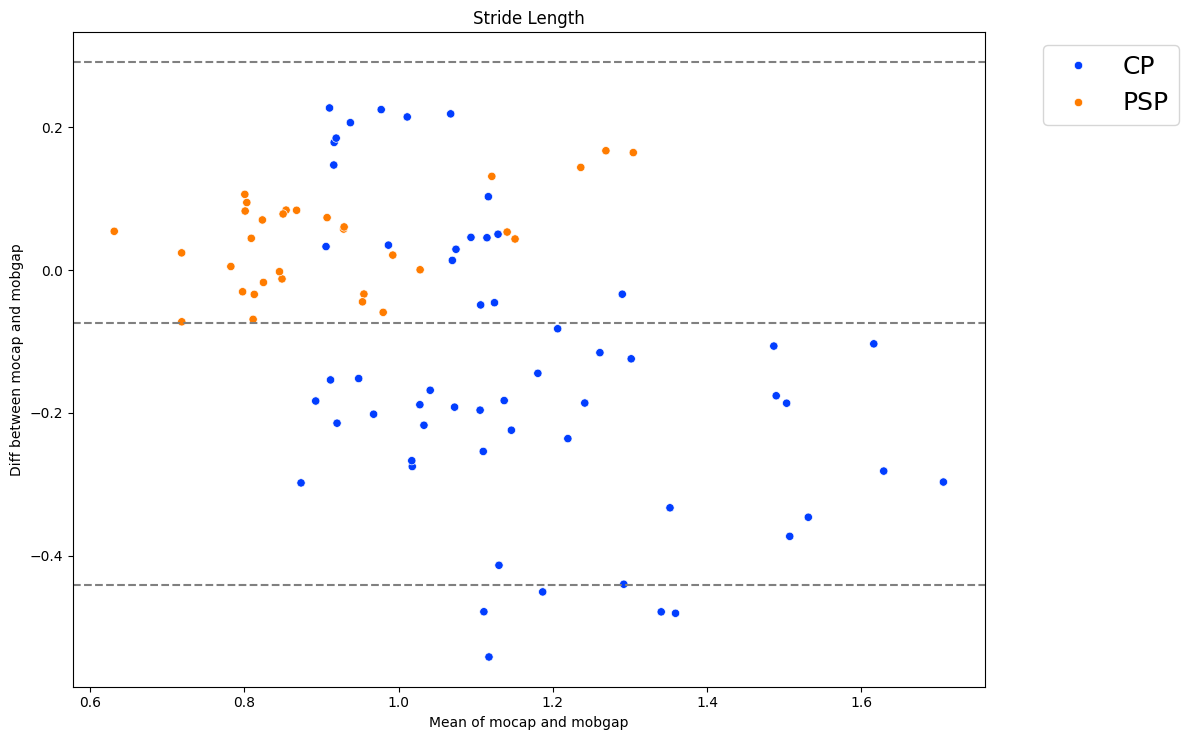

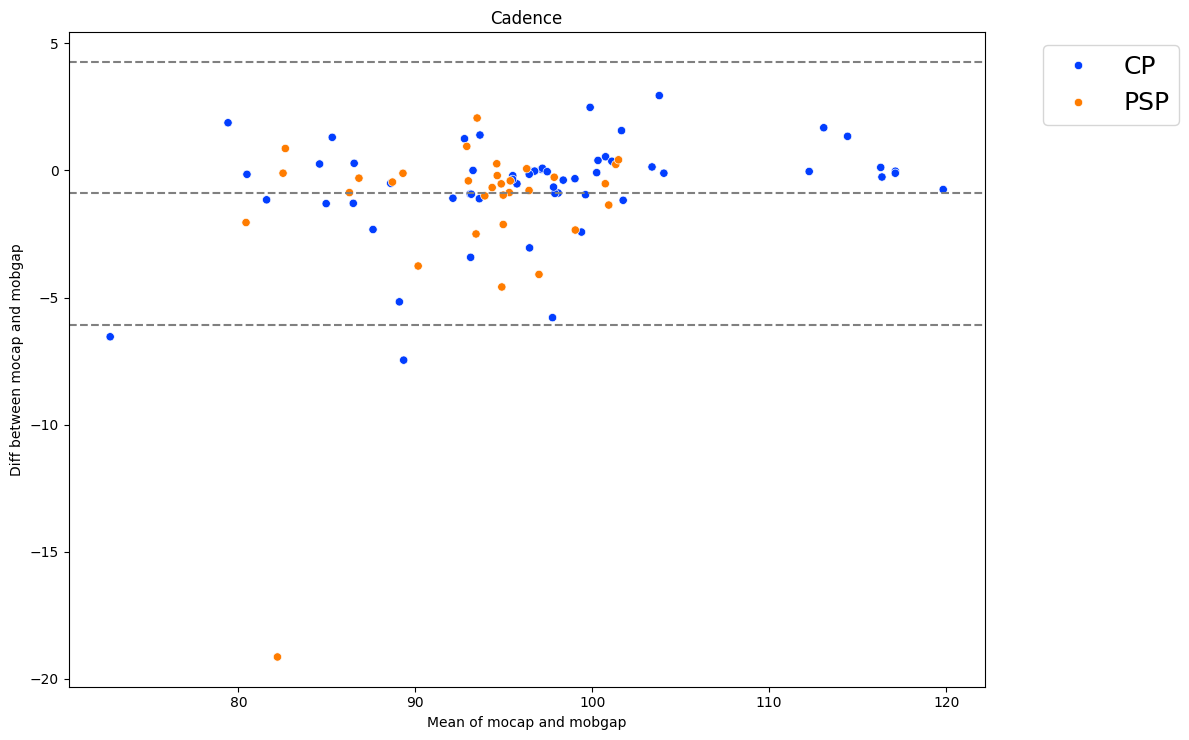

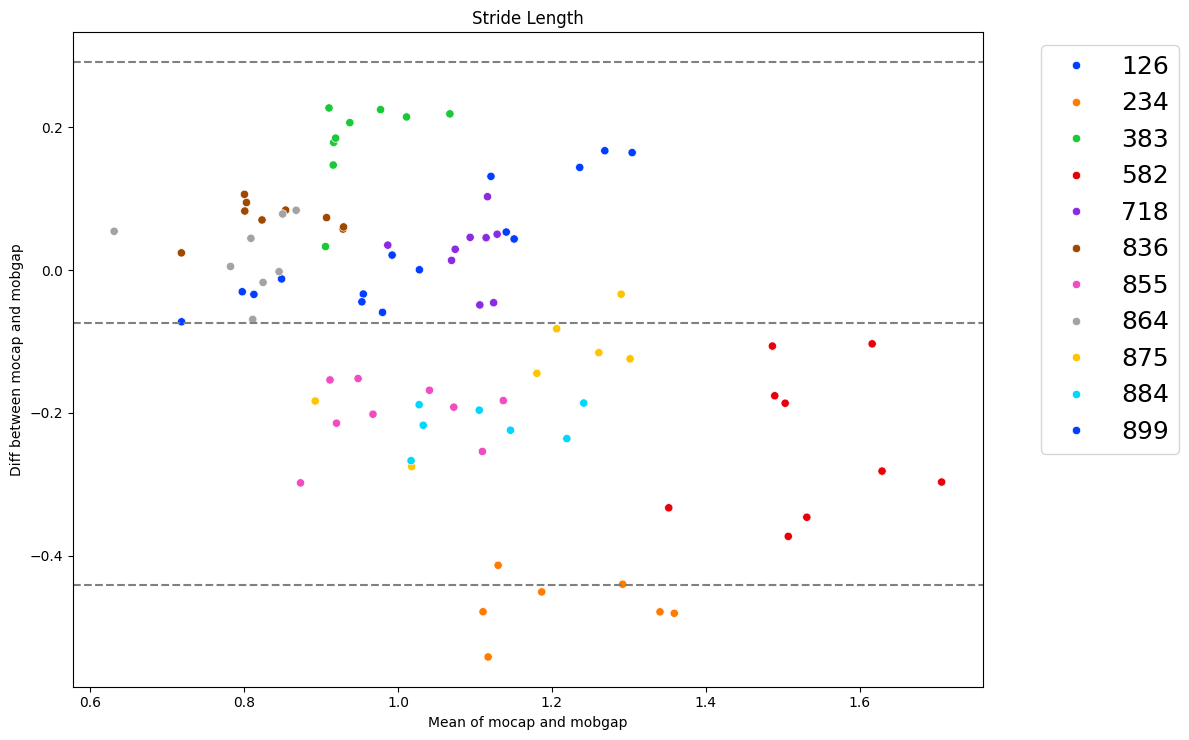

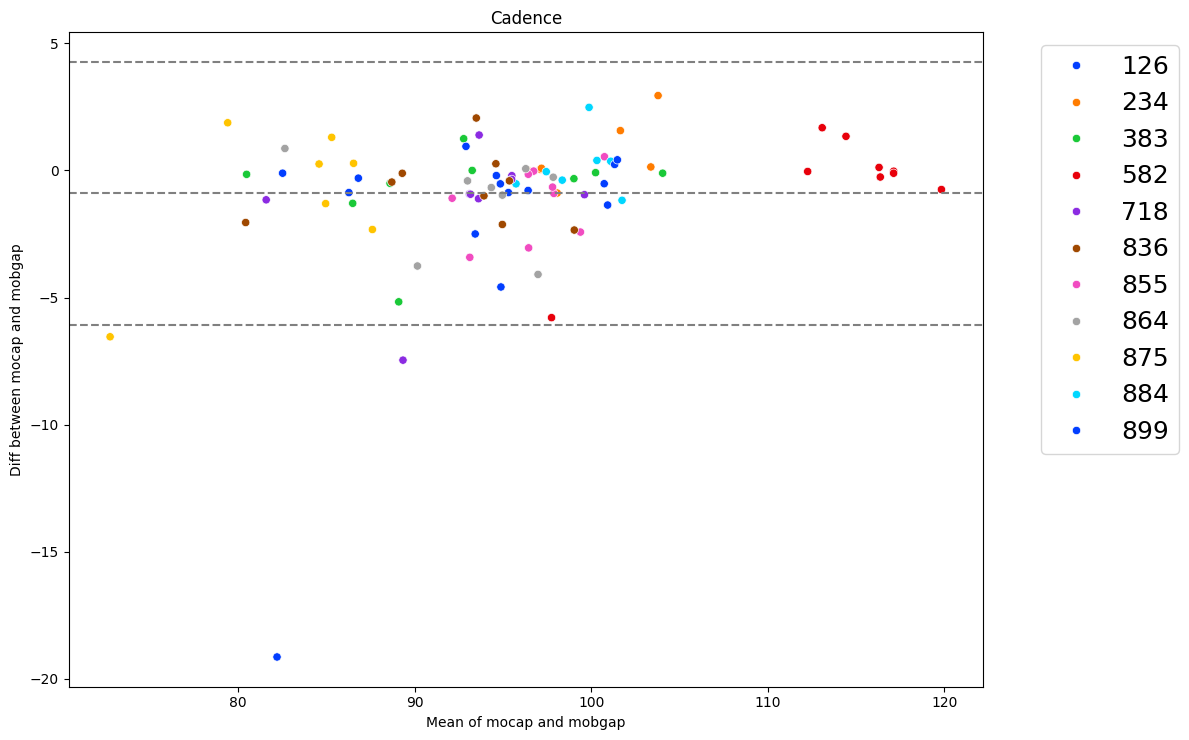

In [56]:
all_metrics = pd.read_csv("In-Lab Parameters/all_metrics.csv")

all_metrics = all_metrics[all_metrics["cohort"] != "HA"] # drop HA

subjects = all_metrics["subject"].unique()

# wb-level stats stats
# calculate IC results into metrics dataframe
mask = all_metrics["IC_TPs"] > 0  # only keep rows where wb_ID is not NaN
all_metrics.loc[mask, "IC_Sensitivity"] = (
    all_metrics.loc[mask, "IC_TPs"] /
    (all_metrics.loc[mask, "IC_TPs"] + all_metrics.loc[mask, "IC_FNs"])
)
all_metrics.loc[mask, "IC_Positive_Predictive_Value"] = (
    all_metrics.loc[mask, "IC_TPs"] /
    (all_metrics.loc[mask, "IC_TPs"] + all_metrics.loc[mask, "IC_FPs"])
)
all_metrics.loc[mask, "IC_F1_Score"] = (
    (2*all_metrics.loc[mask, "IC_Sensitivity"]*all_metrics.loc[mask, "IC_Positive_Predictive_Value"]) /
    (all_metrics.loc[mask, "IC_Sensitivity"]+all_metrics.loc[mask, "IC_Positive_Predictive_Value"])
)

# subject-level stats
subject_metrics = pd.DataFrame(columns = ["Subject", "Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"])
for subject in subjects:
    cur_sub_metrics = all_metrics[all_metrics["subject"] == subject]
    subject_metrics_ser = pd.Series(index=["Subject", "Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"], dtype=object)
    subject_metrics_ser["Subject"] = subject
    subject_metrics_ser["Cohort"] = cur_sub_metrics["cohort"].iloc[0]
    subject_metrics_ser = calc_metrics(subject_metrics_ser, cur_sub_metrics)
    subject_metrics = pd.concat([subject_metrics, subject_metrics_ser.to_frame().T])

# cohort-level stats
cohort_metrics = pd.DataFrame(columns = ["Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"])
cohorts = all_metrics["cohort"].unique()
for cohort in cohorts:
    cur_cohort_metrics = all_metrics[all_metrics["cohort"] == cohort]
    cohort_metrics_ser = pd.Series(index = ["Cohort", "Accuracy", "Sensitivity", "Specificity", "Positive Predictive Value", "F1 Score"], dtype=object)
    cohort_metrics_ser["Cohort"] = cohort
    cohort_metrics_ser = calc_metrics(cohort_metrics_ser, cur_cohort_metrics)
    cohort_metrics = pd.concat([cohort_metrics, cohort_metrics_ser.to_frame().T])

# display all stats
display(all_metrics)
display(subject_metrics)
display(cohort_metrics)

bland_altman_plot(all_metrics.loc[mask, "stride_length_mocap"], all_metrics.loc[mask, "stride_length_mobgap"], all_metrics.loc[mask, "cohort"], "Stride Length")
bland_altman_plot(all_metrics.loc[mask, "cadence_mocap"], all_metrics.loc[mask, "cadence_mobgap"], all_metrics.loc[mask, "cohort"], "Cadence")
bland_altman_plot(all_metrics.loc[mask, "stride_length_mocap"], all_metrics.loc[mask, "stride_length_mobgap"], all_metrics.loc[mask, "subject"], "Stride Length")
bland_altman_plot(all_metrics.loc[mask, "cadence_mocap"], all_metrics.loc[mask, "cadence_mobgap"], all_metrics.loc[mask, "subject"], "Cadence")

In [57]:
cohorts = ["CP", "PSP"]

for cohort in cohorts:
    print("###################################################")
    print(f"####################### {cohort} ########################")
    print("###################################################")
    cohort_metrics = all_metrics[all_metrics["cohort"] == cohort]
    _, _, mae_stride_length, upper_loa_stride_length, lower_loa_stride_length = errors(cohort_metrics["stride_length_mobgap"], cohort_metrics["stride_length_mocap"])
    _, _, mae_cadence, upper_loa_cadence, lower_loa_cadence = errors(cohort_metrics["cadence_mobgap"], cohort_metrics["cadence_mocap"])
    _, _, mae_walking_speed, upper_loa_walking_speed, lower_loa_walking_speed = errors(cohort_metrics["walking_speed_mobgap"], cohort_metrics["walking_speed_mocap"])

    print()
    print(f"Mean IC Sensitivity = {cohort_metrics["IC_Sensitivity"].mean()}")
    print(f"Mean IC Positive Predictive Value = {cohort_metrics["IC_Positive_Predictive_Value"].mean()}")
    print(f"Mean IC F1 Score = {cohort_metrics["IC_F1_Score"].mean()}")
    print()
    print(f"MAE stride length = {mae_stride_length} [{lower_loa_stride_length}, {upper_loa_stride_length}]")
    print(f"MAE cadence = {mae_cadence} [{lower_loa_cadence}, {upper_loa_cadence}]")
    print(f"MAE walking speed = {mae_walking_speed} [{lower_loa_walking_speed}, {upper_loa_walking_speed}]")
    print()

###################################################
####################### CP ########################
###################################################

Mean IC Sensitivity = 0.9747108677453726
Mean IC Positive Predictive Value = 0.9234051451400065
Mean IC F1 Score = 0.9471053531344595

MAE stride length = 0.20741686991001929 [-0.04644579596751891, 0.4612795357875575]
MAE cadence = 1.2406976441428412 [-1.9346519547508718, 4.416047243036554]
MAE walking speed = 0.19020358182885277 [-0.05149573010735789, 0.4319028937650634]

###################################################
####################### PSP ########################
###################################################

Mean IC Sensitivity = 0.9723317028258877
Mean IC Positive Predictive Value = 0.9300034601877776
Mean IC F1 Score = 0.9486765763935303

MAE stride length = 0.06301532365256862 [-0.02168069763957567, 0.1477113449447129]
MAE cadence = 1.7284129549290355 [-4.820243170241227, 8.277069080099297]
MAE walking speed 